In [46]:
import mdtraj as md
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [54]:
plt.rcParams.update({
    'font.size': 8,            # Default font size
    'axes.labelsize': 9,       # Axis title size
    'axes.titlesize': 9,       
    'xtick.labelsize': 8,      # X tick labels
    'ytick.labelsize': 8,      # Y tick labels
    'legend.fontsize': 8,      # Legend
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans', 'Liberation Sans', 'sans-serif'],# Use Arial or Helvetica
    'pdf.fonttype': 42         # Editable text in PDFs
})

In [ ]:
output_path='/global/cfs/cdirs/m4704/100125_Nature_Com_data/single_conformation/nmr'

In [ ]:
ref_path='/global/cfs/cdirs/m4704/100125_Nature_Com_data/Apo_holo_data/pdbs'

In [ ]:
openfold_path='/global/cfs/cdirs/m4704/100125_Nature_Com_data/single_conformation/af'

In [79]:
conditions = [
    AF_result['rmsd'] < 1,
    (AF_result['rmsd'] >= 1) & (AF_result['rmsd'] <= 5),
    AF_result['rmsd'] > 5
]
choices = ['High', 'Medium', 'Low']

AF_result['OpenFold Accuracy'] = np.select(conditions, choices, default='Unknown')

In [80]:
NMR_RMSD=NMR_result.merge(AF_result,on='name',suffixes=['','y'])[['name','rmsd','saxs_kldiv','rg_diff_A','type','OpenFold Accuracy']]
AF_RMSD=AF_result[['name','rmsd','saxs_kldiv','rg_diff_A','type','OpenFold Accuracy']]
plot_rmsd=pd.concat([NMR_RMSD,AF_RMSD])

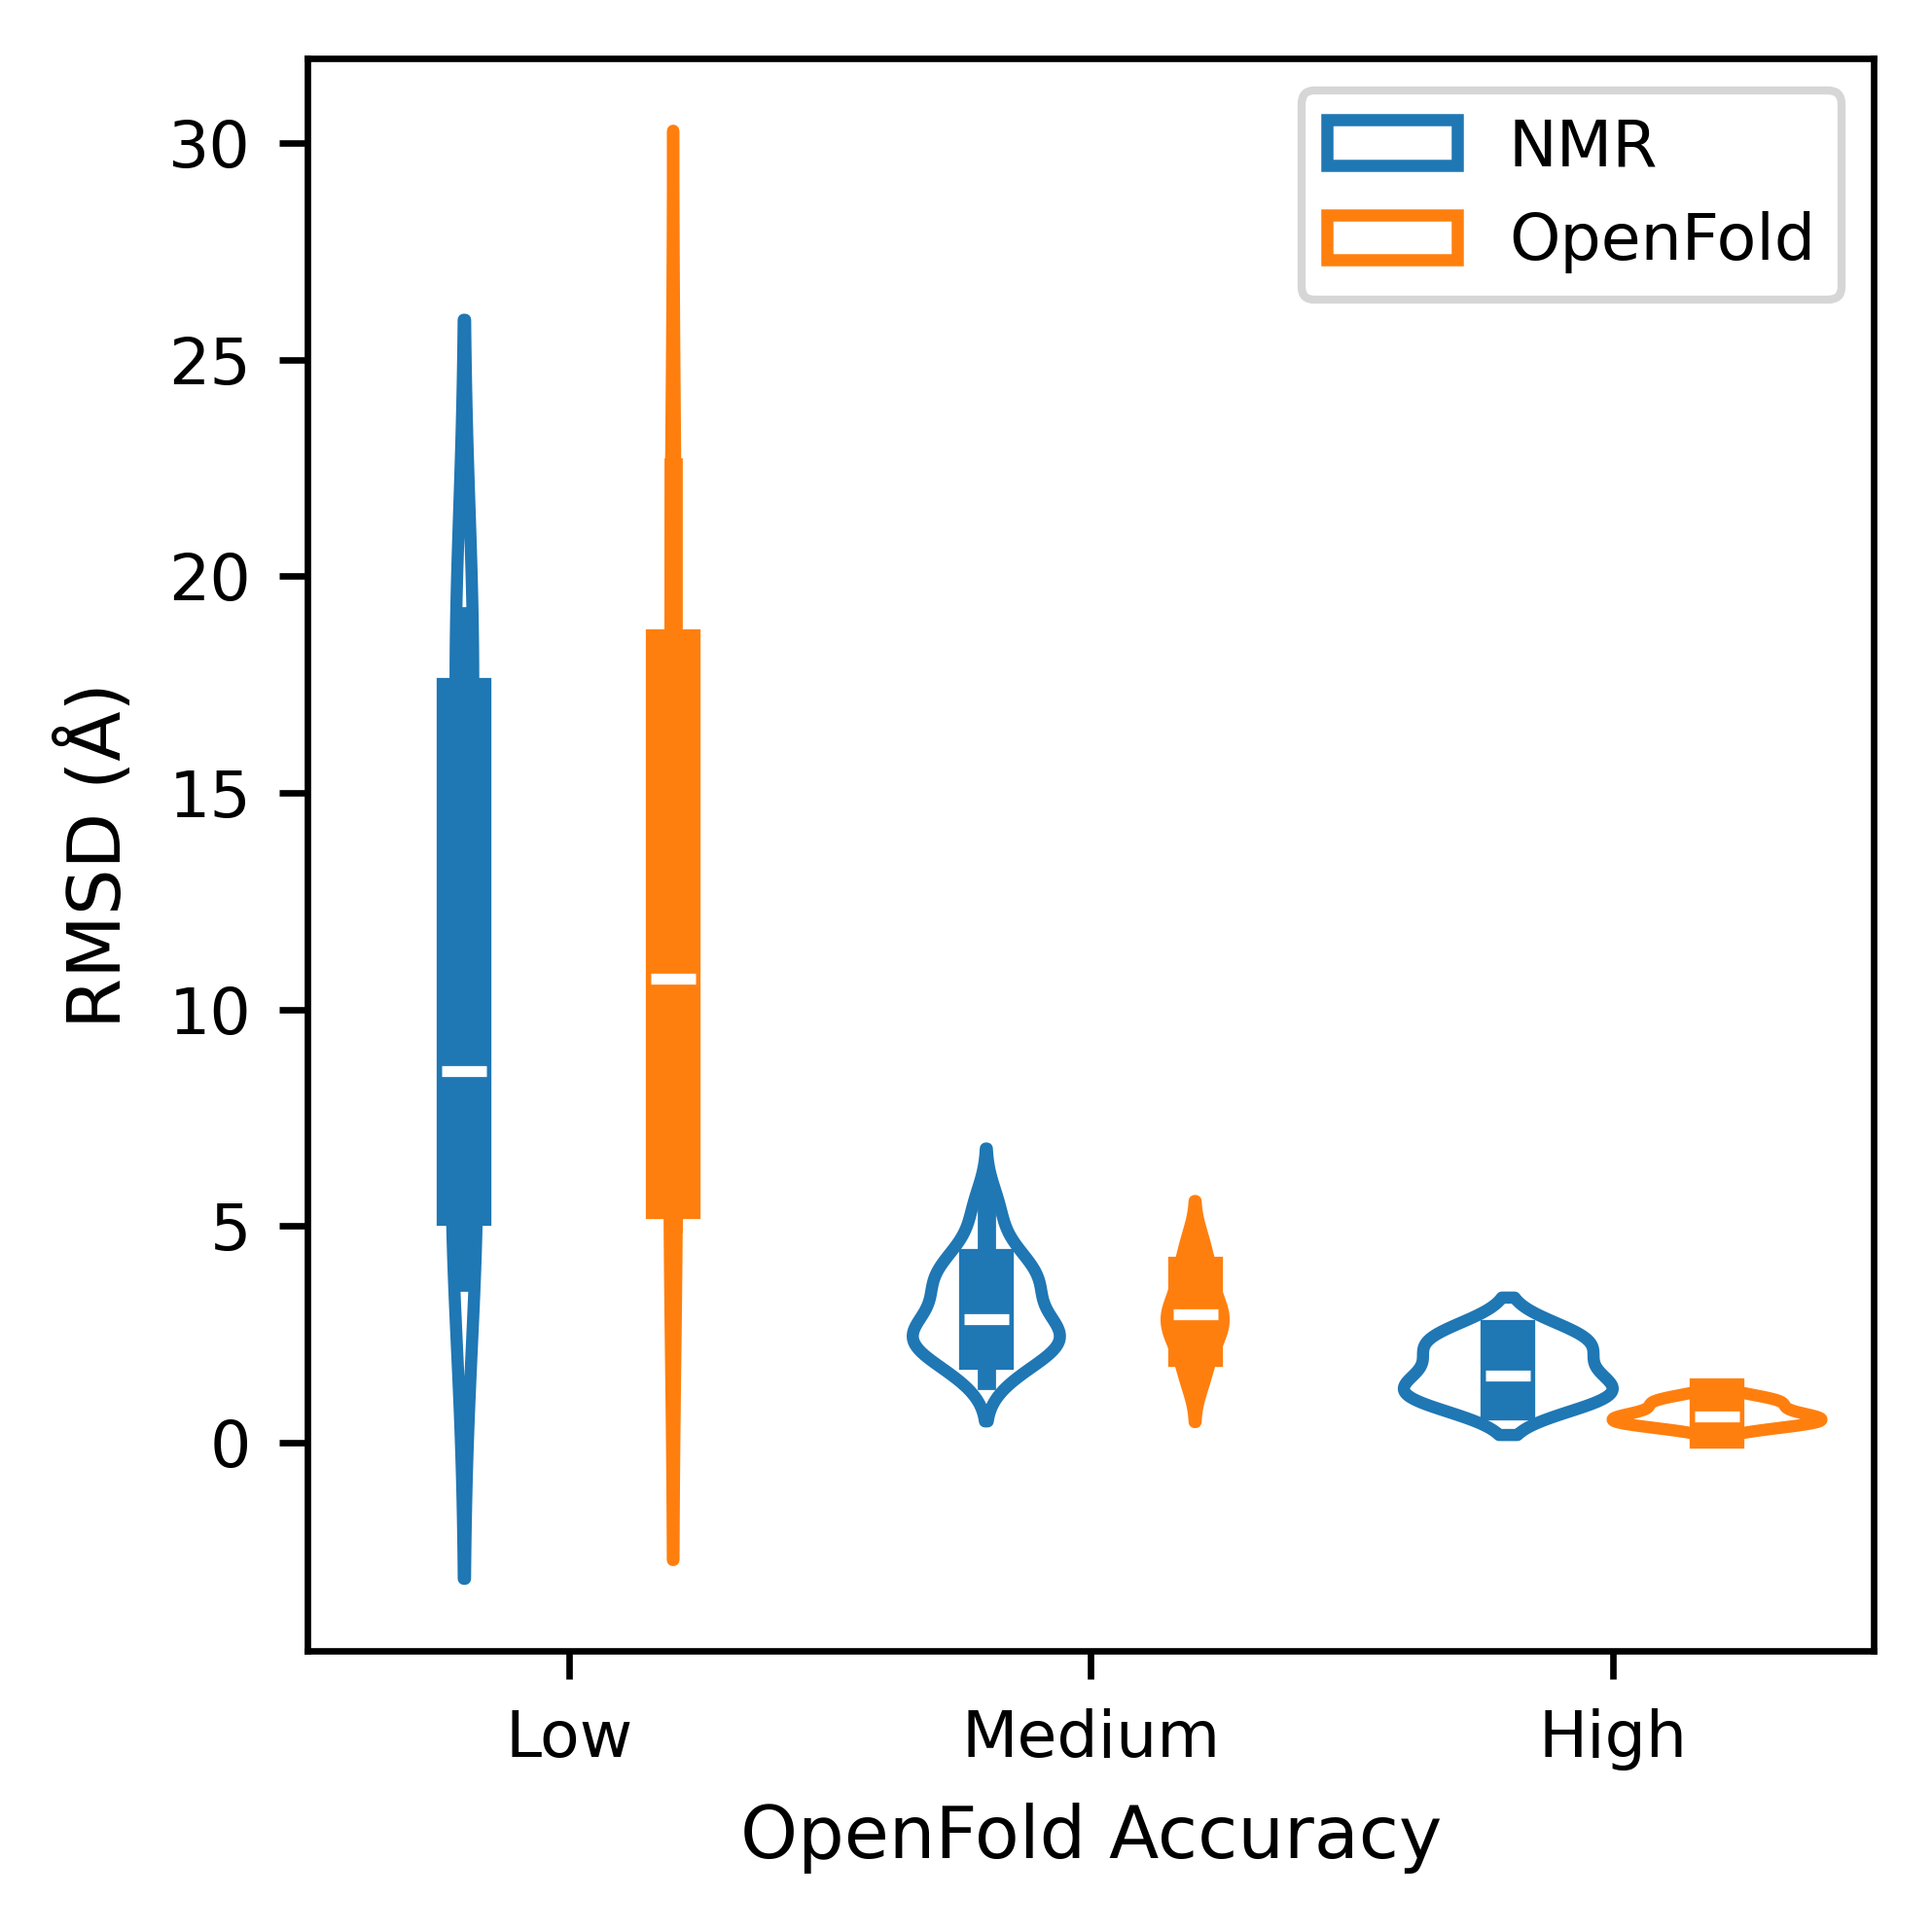

In [81]:
fig, ax = plt.subplots(figsize=(3.35, 3.35), dpi=600) # Single-column, high-res

sns.violinplot( y='rmsd',x='OpenFold Accuracy',hue='type',fill=False, data=plot_rmsd, ax=ax)
ax.set_xlabel('OpenFold Accuracy', labelpad=4)
ax.set_ylabel('RMSD (Å)', labelpad=4)
#ax.set_title('Violin Plot Example', fontsize=9, pad=8)

# Remove legend if it just duplicates x info, or set title to None
legend = ax.get_legend()
if legend:
    legend.set_title(None)

plt.tight_layout()
plt.savefig('RMSD comparison')

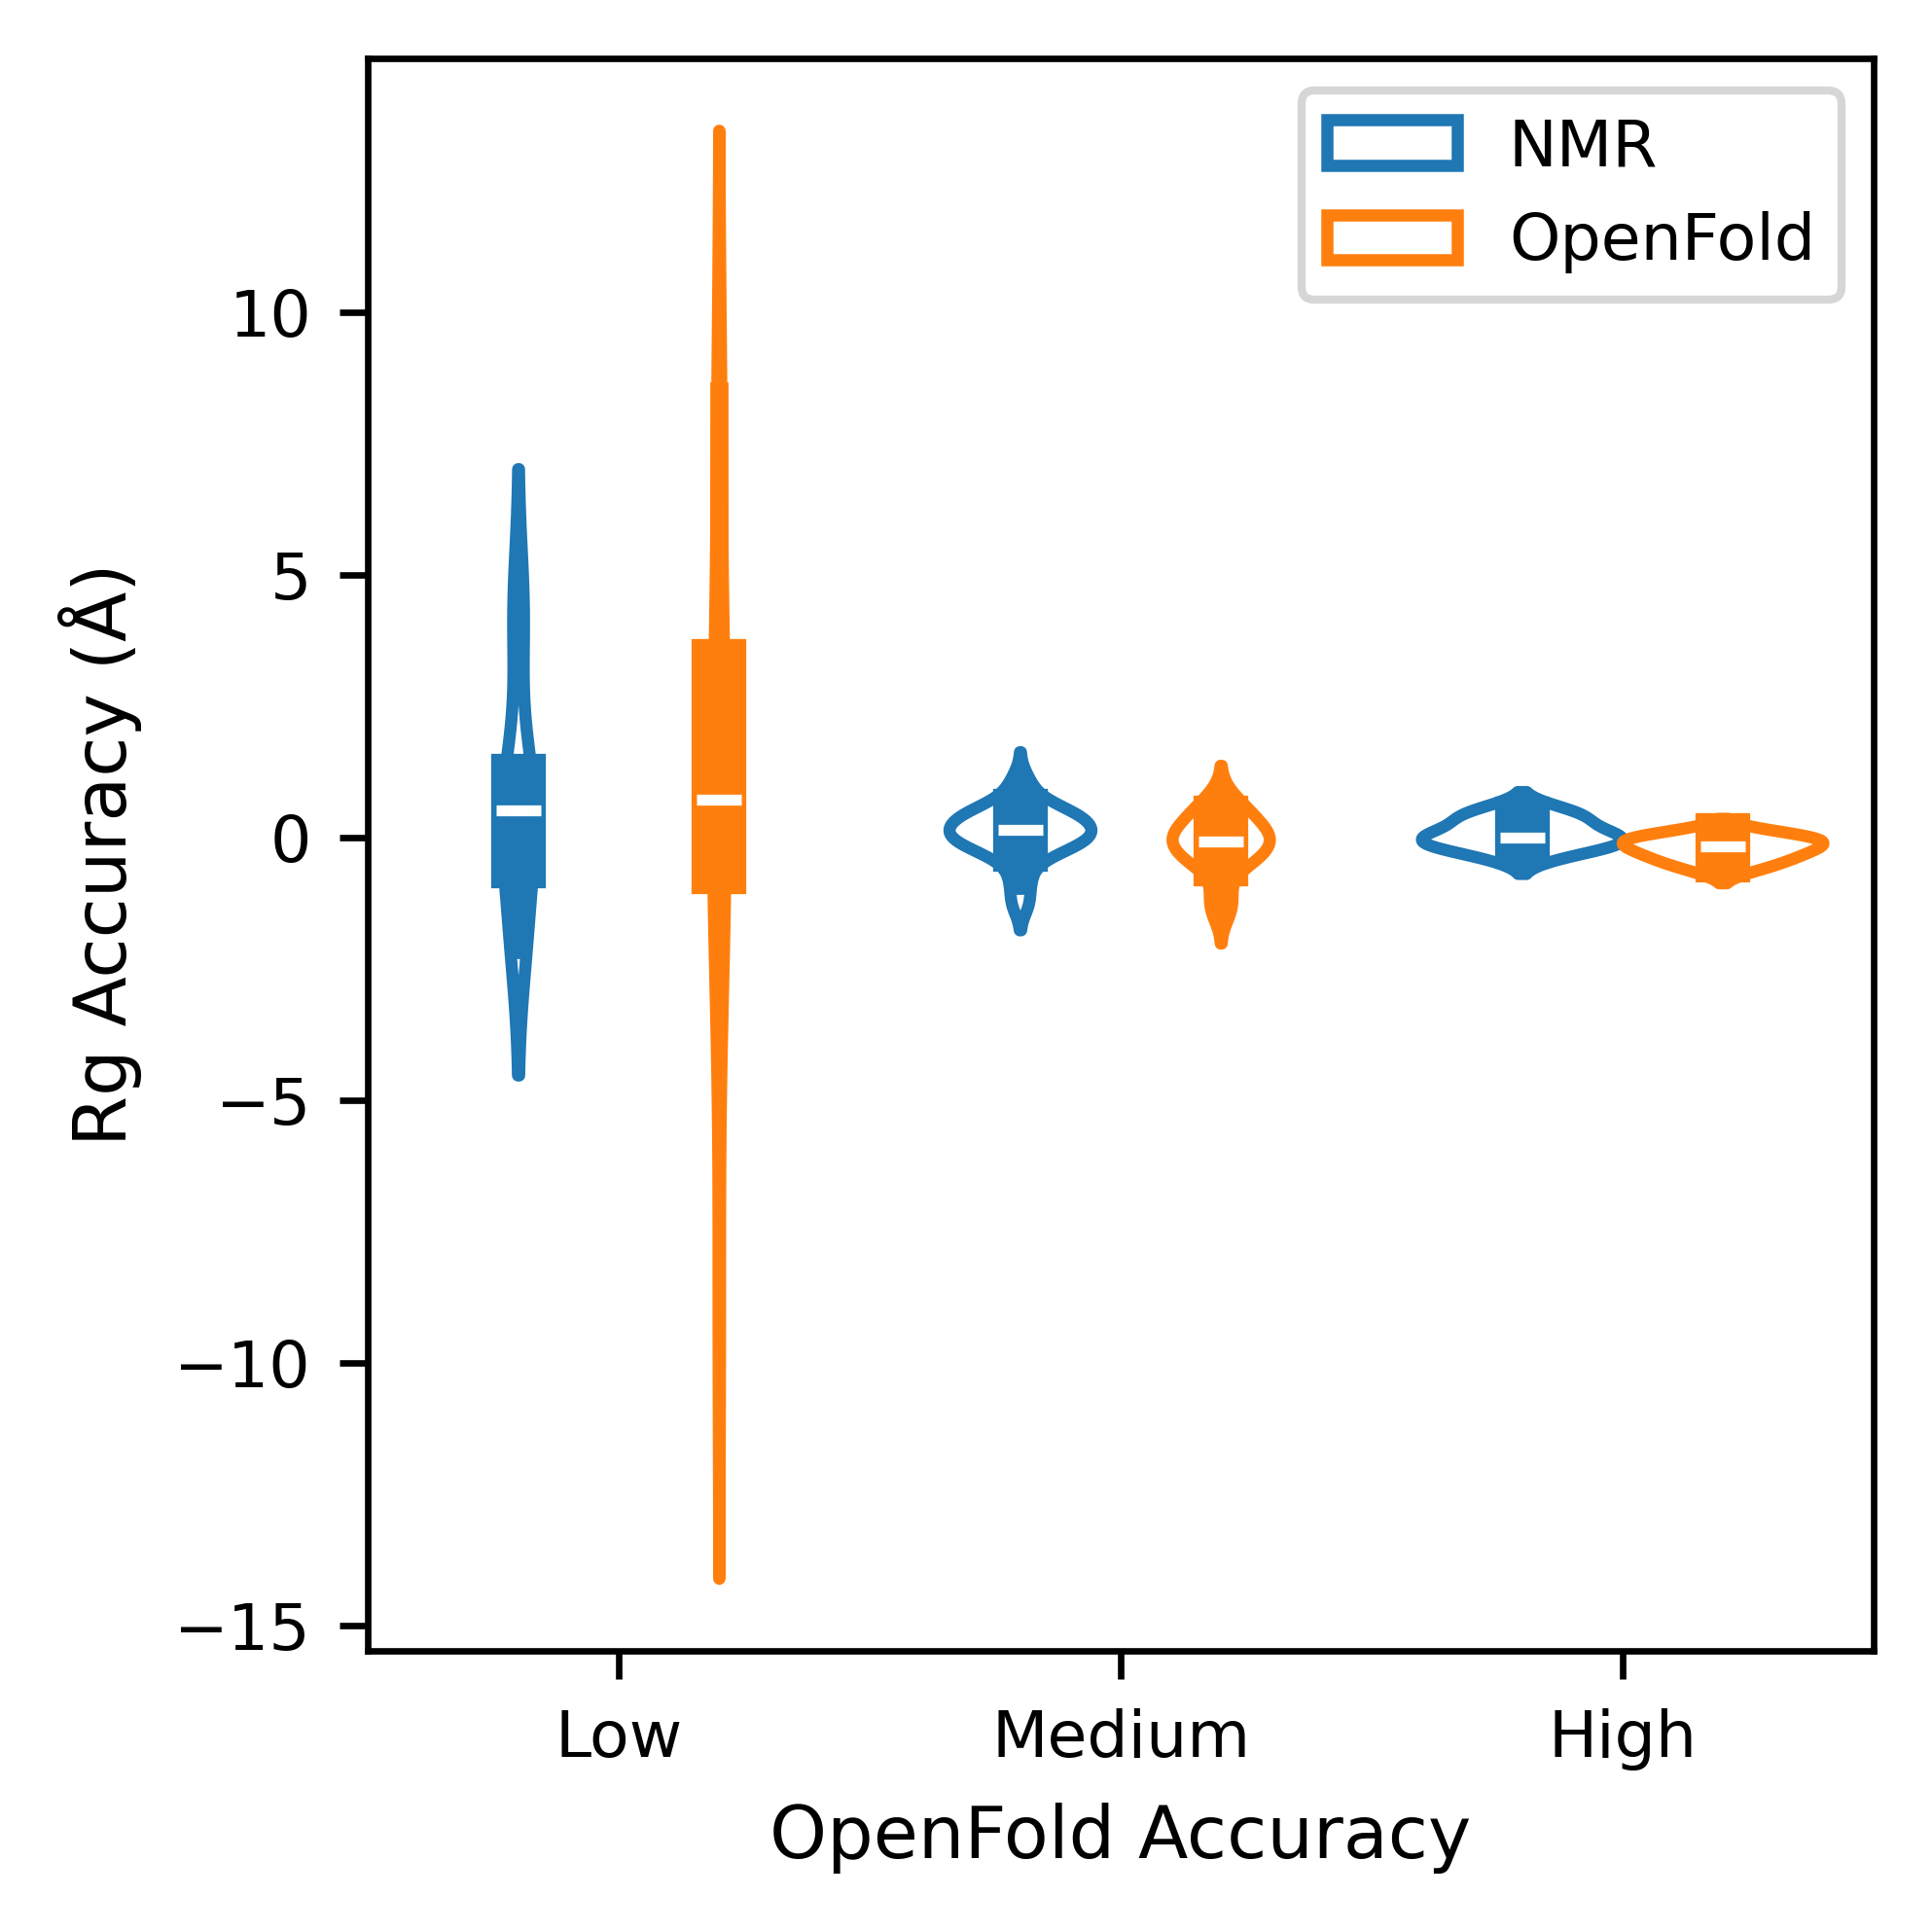

In [86]:
fig, ax = plt.subplots(figsize=(3.35, 3.35), dpi=600) # Single-column, high-res

sns.violinplot( y='rg_diff_A',x='OpenFold Accuracy',hue='type',fill=False, data=plot_rmsd, ax=ax)
ax.set_xlabel('OpenFold Accuracy', labelpad=4)
ax.set_ylabel('Rg Accuracy (Å)', labelpad=4)
#ax.set_title('Violin Plot Example', fontsize=9, pad=8)

# Remove legend if it just duplicates x info, or set title to None
legend = ax.get_legend()
if legend:
    legend.set_title(None)

plt.tight_layout()
plt.savefig('Rg comparison')